# L2. Store and Recall

Store personal notes as vectors in **Qdrant Edge**, an embedded engine with no server and no network. One question, asked three times, walks a memory's life: unanswered on the empty store, recalled by meaning once stored, and gone after you forget it. The store is plain files that survive a restart.

## 1. Ask before there's anything to remember

The model is already on the device. Watch what happens when we ask it something before storing a single memory.

In [1]:
from helper import add_filler, before_after, embed_query, embed_query_ms, embed_text, fresh_start, latency_hist, load_memories, lookup_times, text_search

from qdrant_edge import EdgeShard, EdgeConfig, EdgeVectorParams, Distance, Query, QueryRequest

SHARD_DIR = fresh_start("./coffee_shard")

config = EdgeConfig(
    vectors={
        "text": EdgeVectorParams(size=768, distance=Distance.Cosine),
    }
)
shard = EdgeShard.create(SHARD_DIR, config)
print("Empty shard created at", SHARD_DIR)

Empty shard created at ./coffee_shard


In [2]:
question = "where can I sit outside for a latte?"
hits = shard.query(
    QueryRequest(
        query=Query.Nearest(embed_query(question), using="text"),
        limit=3,
        with_payload=True,
    )
)
print("Q:", question)
print("Memories found:", len(hits))

Q: where can I sit outside for a latte?
Memories found: 0


## 2. The memories

A day of notes ships with the course. Here are the first few.

In [3]:
notes = load_memories(
    "./ro_shared_data/memories.json",
    source_type="text",
)
for m in notes[:6]:
    print(f"[{m['category']:>8}] {m['note']}")
print("...")
print(len(notes), "text notes")

[    food] Great little coffee place on 5th with outdoor seating and fast wifi
[    work] Standup with Sarah moved to Thursday to review the Q3 roadmap
[ errands] Pick up dry cleaning before Friday, ticket is on the fridge
[    work] Idea: batch the weekly report so it drafts itself every Monday
[  social] Mum's new address is 14 Elm Court, buzzer 3
[shopping] Liked the black and white running shoes at the mall, about $45
...
20 text notes


## 3. Turn notes into vectors, on the device

Each note becomes a vector of 768 numbers, computed by a small local model. Notes with similar meanings get similar numbers.

In [4]:
vectors = embed_text([m["note"] for m in notes])
print(f"Embedded {len(vectors)} notes with Nomic (768 dimensions)")

Embedded 20 notes with Nomic (768 dimensions)


## 4. Store the memories

One point per note: the vector carries the meaning, the note itself rides along as payload.

In [5]:
from qdrant_edge import Point, UpdateOperation

points = [
    Point(id=m["id"], vector={"text": vector}, payload=m)
    for m, vector in zip(notes, vectors)
]
shard.update(UpdateOperation.upsert_points(points))
shard.optimize()
print("Stored", shard.info().points_count, "memories")

Stored 20 memories


## 5. Ask again, now it remembers

Same question, same call. Now the closest memories come back, ranked by meaning.

In [6]:
hits = shard.query(
    QueryRequest(
        query=Query.Nearest(embed_query(question), using="text"),
        limit=3,
        with_payload=True,
    )
)
print("Q:", question, "\n")
for h in hits:
    print(f"  {h.score:.3f}  {h.payload['note']}")

Q: where can I sit outside for a latte? 

  0.653  Great little coffee place on 5th with outdoor seating and fast wifi
  0.590  Found a quiet cafe with good wifi to work from near the park
  0.511  Coffee run to the espresso bar near the office


## 6. How fast is local recall?

Grow the store to 5,020 memories, then time both halves of a local answer: embedding the query, and the vector lookup itself.

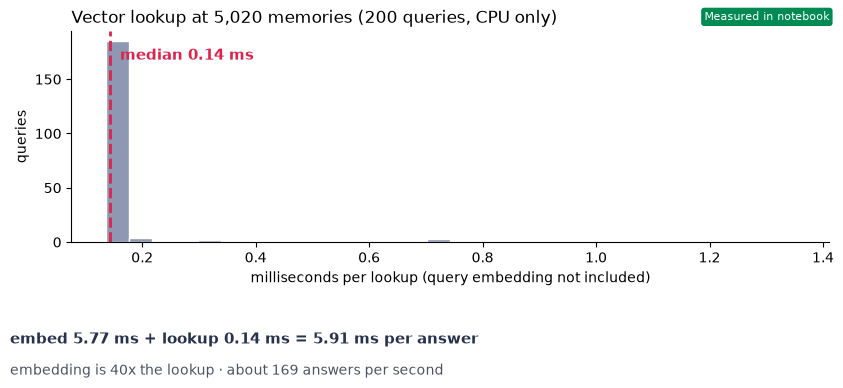

In [7]:
n = add_filler(shard, 5000)

query_vector = embed_query("coffee")
timings = lookup_times(shard, query_vector)

latency_hist(timings, n, embed_ms=embed_query_ms("coffee"))

## 7. Forget a memory

Delete exactly one memory, then ask one more time.

In [8]:
forgotten = hits[0]
shard.update(UpdateOperation.delete_points([forgotten.id]))
shard.optimize()
print("Forgot:", forgotten.payload["note"])

Forgot: Great little coffee place on 5th with outdoor seating and fast wifi


In [9]:
hits_after = text_search(shard, question, limit=3)
before_after(
    question,
    "Before forgetting",
    [f"{h.score:.3f}  {h.payload['note']}" for h in hits],
    "After forgetting",
    [f"{h.score:.3f}  {h.payload['note']}" for h in hits_after],
    legend="✗ forgotten · ✓ still remembered",
)

query: "where can I sit outside for a latte?"
✗ forgotten · ✓ still remembered

Before forgetting:
  ✗ 0.653  Great little coffee place on 5th with outdoor seating and fast wifi
    0.590  Found a quiet cafe with good wifi to work from near the park
    0.511  Coffee run to the espresso bar near the office

After forgetting:
  ✓ 0.590  Found a quiet cafe with good wifi to work from near the park
  ✓ 0.511  Coffee run to the espresso bar near the office
  ✓ 0.457  New bakery on the corner does an amazing morning cronut
